To start we are going to create function to connect to db and view head of data after cleaning to verify it is working.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Function to connect to SQLite database
def sql_connect():
    """Connect to SQLite combined_data.db"""
    return sqlite3.connect('combined_data.db')

#Connect and query combined data db to verify
with sql_connect() as conn:
    query = 'SELECT * FROM combined_table'
    df = pd.read_sql_query(query, conn)

# Display the first few rows of the DataFrame
print(df.head())

# Close the connection
conn.close()




   ages  list_price  num_reviews  piece_count  play_star_rating  \
0  6-12       29.99          2.0          277               4.0   
1  6-12       19.99          2.0          168               4.0   
2  6-12       12.99         11.0           74               4.3   
3   12+       99.99         23.0         1032               3.6   
4   12+       79.99         14.0          744               3.2   

                                           prod_desc  set_number  \
0  Catapult into action and take back the eggs fr...       75823   
1  Launch a flying attack and rescue the eggs fro...       75822   
2  Chase the piggy with lightning-fast Chuck and ...       75821   
3  Explore the architecture of the United States ...       21030   
4  Recreate the Solomon R. Guggenheim Museum® wit...       21035   

                                      prod_long_desc review_difficulty  \
0  Use the staircase catapult to launch Red into ...           Average   
1  Pilot Pig has taken off from Bird Isl

Setup additional functions to pull details on provided value for specific column names.

In [2]:
def get_data_by_review_difficulty(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where review_difficulty matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the review_difficulty column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['review_difficulty'] == target_value]
    return filtered_df

# Test the get data by set_number by pulling data for set number 75821.0
review_difficulty_easy = get_data_by_review_difficulty(df, 'Easy')
print("\nData where review difficulty is 'Easy':")
print(review_difficulty_easy)


Data where review difficulty is 'Easy':
     ages  list_price  num_reviews  piece_count  play_star_rating  \
1    6-12       19.99          2.0          168               4.0   
2    6-12       12.99         11.0           74               4.3   
12    12+       29.99          7.0          361               4.2   
15    10+       19.99          1.0          234               3.0   
20    10+        9.99          2.0          105               3.0   
..    ...         ...          ...          ...               ...   
677  7-14       29.99          6.0          341               4.4   
679  7-14       19.99          8.0          217               4.1   
680  7-14       19.99         18.0          233               4.6   
682  6-14        9.99         11.0          109               4.5   
683   10+        9.99          7.0          102               4.0   

                                             prod_desc  set_number  \
1    Launch a flying attack and rescue the eggs fro...      

In [3]:
def get_data_by_theme(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where theme_name value matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the theme_name column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['theme_name'] == target_value]
    return filtered_df

# Test the get data by theme_name by pulling data for set theme Architecture
theme_architecture = get_data_by_theme(df, 'Architecture')
print("\nData where theme is 'Architecture':")
print(theme_architecture)


Data where theme is 'Architecture':
   ages  list_price  num_reviews  piece_count  play_star_rating  \
3   12+       99.99         23.0         1032               3.6   
4   12+       79.99         14.0          744               3.2   
7   12+       49.99         24.0          780               4.4   
10  12+       39.99         14.0          386               4.1   
11  12+       34.99         53.0          321               3.2   

                                            prod_desc  set_number  \
3   Explore the architecture of the United States ...       21030   
4   Recreate the Solomon R. Guggenheim Museum® wit...       21035   
7   Recreate Buckingham Palace with LEGO® Architec...       21029   
10    Experience the grandeur of the Arc de Triomphe!       21036   
11  Build your own LEGO® interpretation of the ico...       21019   

                                       prod_long_desc review_difficulty  \
3   Discover the architectural secrets of the icon...           Averag

In [4]:
def get_data_by_year_released(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where year_released value matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the year_released column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['year_released'] == target_value]
    return filtered_df

# Test the get data by year_released by pulling data for 2017
year_2017 = get_data_by_year_released(df, 2017)
print("\nData where year released is '2017':")
print(year_2017)


Data where year released is '2017':
     ages  list_price  num_reviews  piece_count  play_star_rating  \
4     12+       79.99         14.0          744               3.2   
9     12+       39.99         11.0          444               3.6   
10    12+       39.99         14.0          386               4.1   
12    12+       29.99          7.0          361               4.2   
13   7-12      159.99         63.0          847               3.8   
..    ...         ...          ...          ...               ...   
682  6-14        9.99         11.0          109               4.5   
683   10+        9.99          7.0          102               4.0   
684   10+        9.99          5.0           89               3.2   
685    5+        3.99         22.0            8               4.3   
686    5+        3.99         22.0            8               4.3   

                                             prod_desc  set_number  \
4    Recreate the Solomon R. Guggenheim Museum® wit...       210

Setup Visualizations

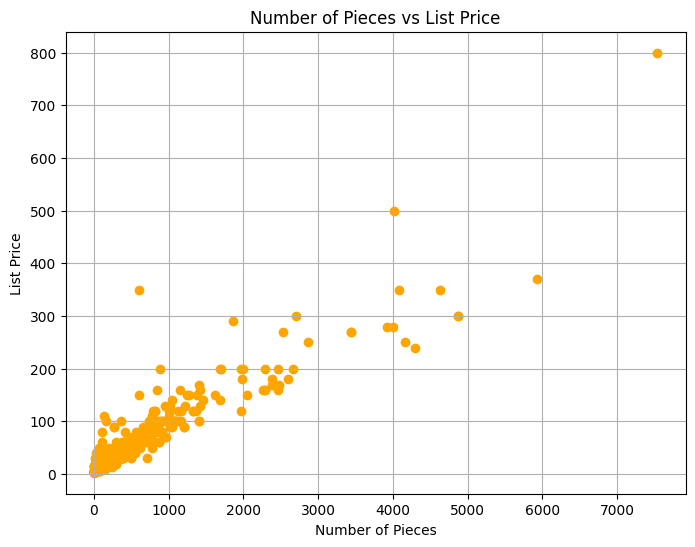

In [5]:
#setup scatter plot 
plt.figure(figsize=(8, 6))
plt.scatter(df['piece_count'], df['list_price'], color='orange')
plt.title('Number of Pieces vs List Price')
plt.xlabel('Number of Pieces')
plt.ylabel('List Price')
plt.grid(True)
plt.show()



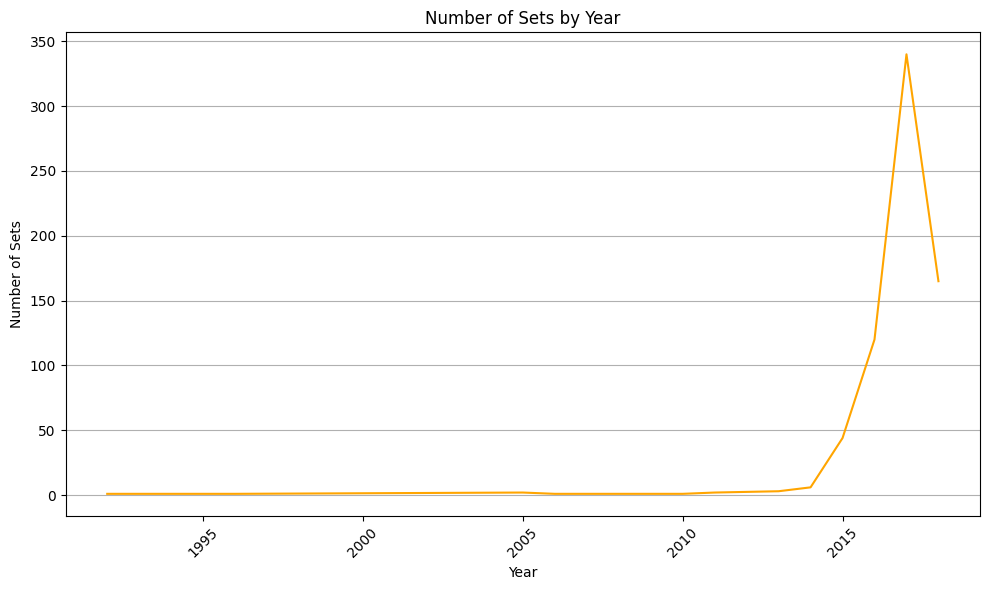

In [6]:
# Create a bar chart based on Year
sets_by_year = df['year_released'].value_counts().sort_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
sets_by_year.plot(kind='line', color='orange')
plt.title('Number of Sets by Year')
plt.xlabel('Year')
plt.ylabel('Number of Sets')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()




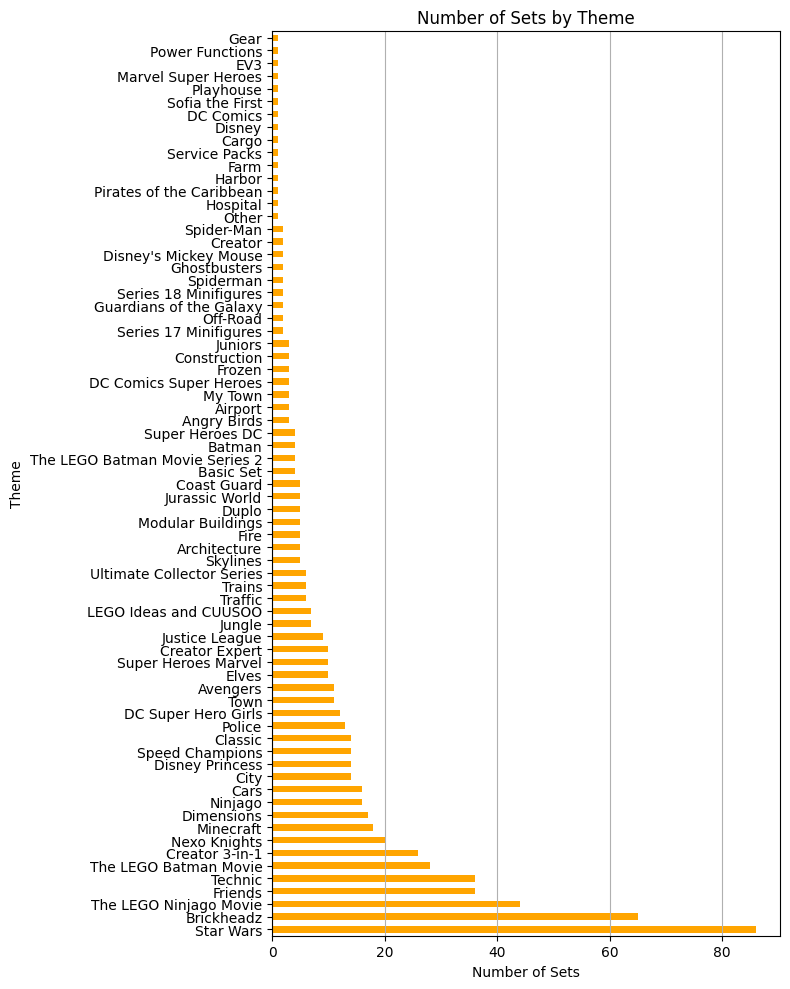

In [7]:
# Create a bar chart based on theme
sets_by_theme = df['theme_name'].value_counts().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(8, 10))
sets_by_theme.plot(kind='barh', color='orange')
plt.title('Number of Sets by Theme')
plt.xlabel('Number of Sets')
plt.ylabel('Theme')
plt.grid(axis='x')
plt.tight_layout()

# Show the plot
plt.show()

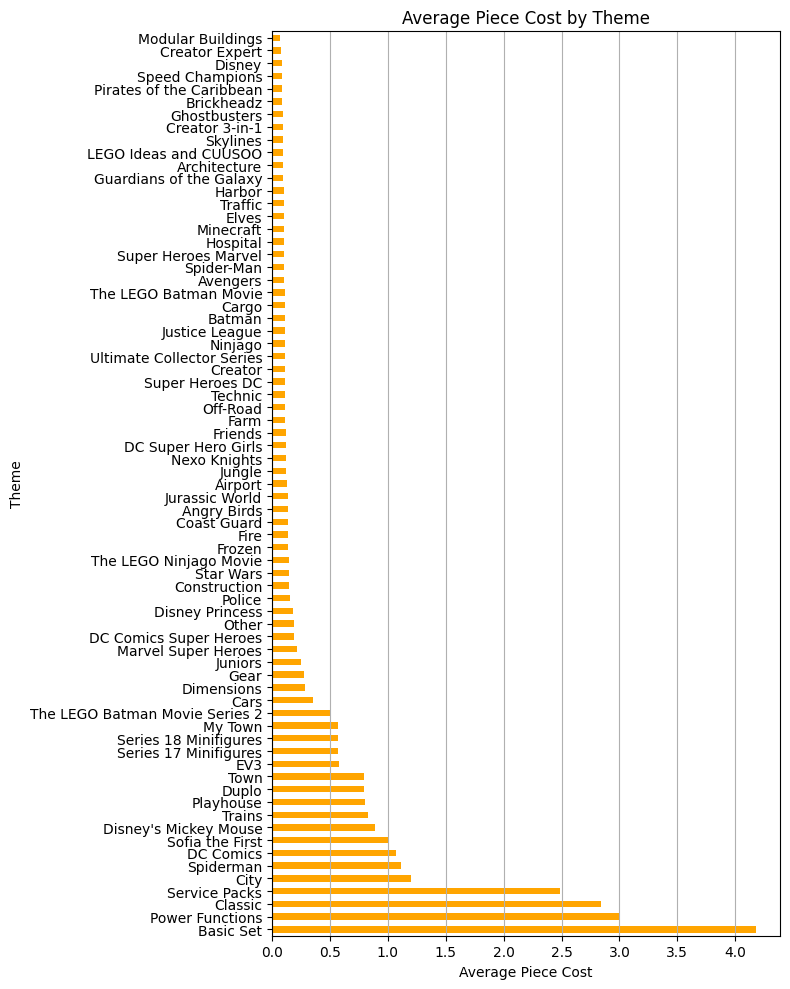

In [8]:
# Create a bar chart based on theme average piece cost
sets_by_theme = df['theme_name'].value_counts().sort_index()

# Calculate the average piece cost by theme
average_piece_cost_by_theme = df.groupby('theme_name')['piece_cost'].mean().sort_values(ascending=False)

# Create a horizontial bar chart
plt.figure(figsize=(8, 10))
average_piece_cost_by_theme.plot(kind='barh', color='orange')
plt.title('Average Piece Cost by Theme')
plt.xlabel('Average Piece Cost')
plt.ylabel('Theme')
plt.grid(axis='x')
plt.tight_layout()

# Show the plot
plt.show()

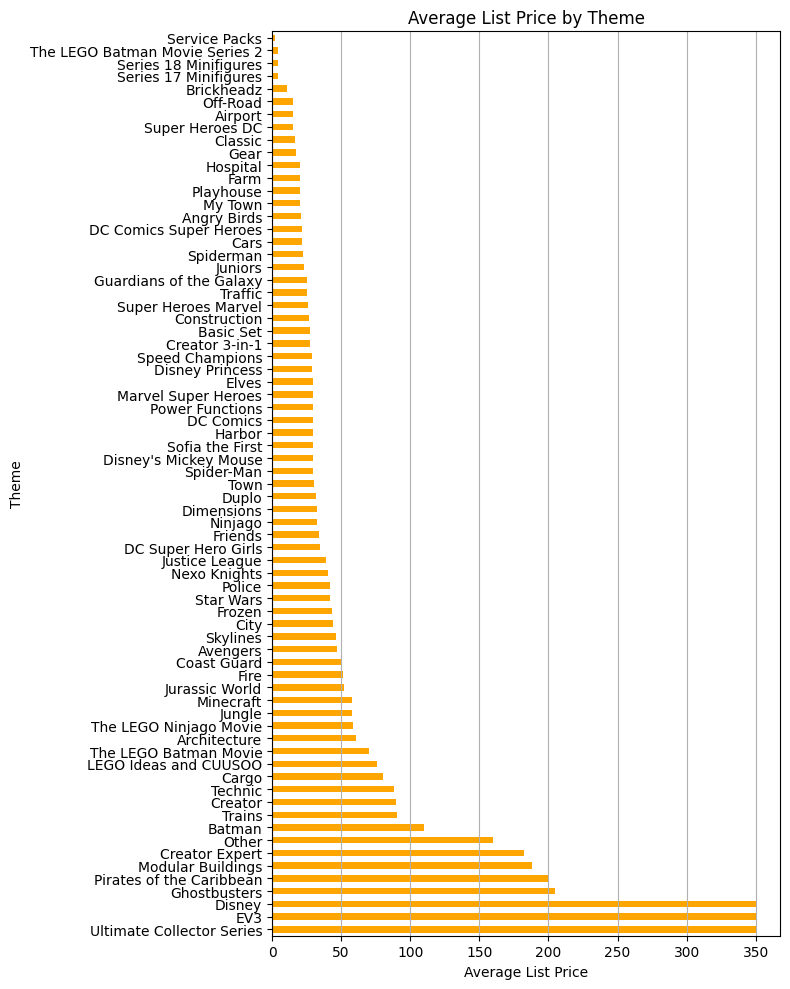

In [9]:
# Create a bar chart based on theme average cost
sets_by_theme = df['theme_name'].value_counts().sort_index()

# Calculate the average piece cost by theme
average_cost_by_theme = df.groupby('theme_name')['list_price'].mean().sort_values(ascending=False)

# Create a horizontial bar chart
plt.figure(figsize=(8, 10))
average_cost_by_theme.plot(kind='barh', color='orange')
plt.title('Average List Price by Theme')
plt.xlabel('Average List Price')
plt.ylabel('Theme')
plt.grid(axis='x')
plt.tight_layout()

# Show the plot
plt.show()